In [4]:
# Import necessary libraries
import pandas as pd  # For data manipulation
from sklearn.model_selection import train_test_split  # For splitting the data into train and test sets
from sklearn.tree import DecisionTreeClassifier  # Decision tree model
from sklearn.metrics import accuracy_score, classification_report  # To evaluate the model
import matplotlib.pyplot as plt


In [6]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df= pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# Define features (X) and target (y)
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]  # Independent variables (features)
y = df['Outcome'] 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

In [11]:
# Train the model on the training data
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

In [12]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
report = classification_report(y_test, y_pred)  # Get detailed classification report


In [13]:
# Print the results
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", report)

Accuracy: 74.68%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # Glucose range
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # BMI range
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

In [ ]:
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [ ]:
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolor='k', s=100)

In [ ]:
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Tree Decision Boundary')

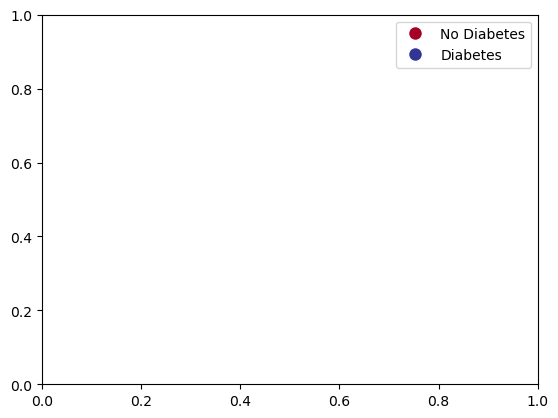

In [16]:
handles = [plt.Line2D([0], [0], marker='o', color='w', label='No Diabetes',
                      markerfacecolor=plt.cm.RdYlBu(0.), markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', label='Diabetes',
                      markerfacecolor=plt.cm.RdYlBu(1.), markersize=10)]
plt.legend(handles=handles)

# Show the plot
plt.show()

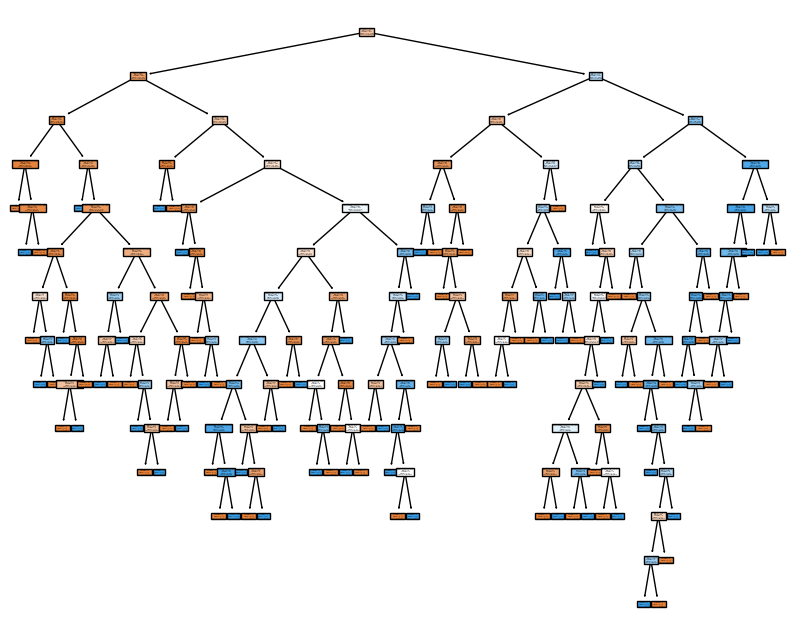

In [14]:
# Optional: Visualize the decision tree (if you have Graphviz installed)
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
tree.plot_tree(clf, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True)
plt.show()